# 💱 Pure Currency Return Analysis — Indian Investor

**Strategy:** On 1st Jan each year, convert INR → USD → Local Currency. Hold for 1 year. Convert back Local → USD → INR. Measure net return.

**Return Components:**
- `INR/USD move` — did INR depreciate vs USD? (positive = INR weakened = you gain on way back)
- `USD/Local move` — did local currency move vs USD?
- `Net Return` = combined effect of both legs

**Years covered:** 2020, 2021, 2022, 2023, 2024, 2025 (6 full years)

**Plus:** Full period total return (compounded across all years)

---

## 1. 📦 Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio

pio.templates.default = 'plotly_white'

COUNTRY_COLORS = {
    'USA':          '#2196F3',
    'UK':           '#9C27B0',
    'TAIWAN':       '#00BCD4',
    'INDONESIA':    '#FF9800',
    'CHINA':        '#E91E63',
    'SOUTH AFRICA': '#4CAF50',
    'BRAZIL':       '#009688',
    'SOUTH KOREA':  '#3F51B5',
    'JAPAN':        '#FF5722',
    'UK':           '#9C27B0',
}

# All foreign countries (India is home — no conversion needed)
COUNTRIES = ['USA', 'UK', 'TAIWAN', 'INDONESIA', 'CHINA', 'SOUTH AFRICA', 'BRAZIL', 'SOUTH KOREA', 'JAPAN']

COUNTRY_COLORS = {
    'USA':          '#2196F3',
    'UK':           '#9C27B0',
    'TAIWAN':       '#00BCD4',
    'INDONESIA':    '#FF9800',
    'CHINA':        '#E91E63',
    'SOUTH AFRICA': '#4CAF50',
    'BRAZIL':       '#009688',
    'SOUTH KOREA':  '#3F51B5',
    'JAPAN':        '#FF5722',
}

YEARS = [2020, 2021, 2022, 2023, 2024, 2025]

print('✅ Setup complete')

✅ Setup complete


## 2. 💾 Download All Currency Data from yFinance

We need **daily data** so we can pick exact 1-Jan and 31-Dec spot rates.

**Tickers:**
- `INR=X` → INR per 1 USD
- `GBPUSD=X` → USD per 1 GBP (we invert to get GBP per USD)
- All others → Local Currency per 1 USD

In [2]:
# Tickers: value = units of LOCAL CURRENCY per 1 USD
# For GBP we invert since yfinance gives USD per GBP
FX_TICKERS = {
    'USA':          None,         # Already USD — only INR/USD leg matters
    'UK':           'GBPUSD=X',   # yfinance: USD per GBP → invert → GBP per USD
    'TAIWAN':       'TWD=X',      # TWD per USD
    'INDONESIA':    'IDR=X',      # IDR per USD
    'CHINA':        'CNY=X',      # CNY per USD
    'SOUTH AFRICA': 'ZAR=X',      # ZAR per USD
    'BRAZIL':       'BRL=X',      # BRL per USD
    'SOUTH KOREA':  'KRW=X',      # KRW per USD
    'JAPAN':        'JPY=X',      # JPY per USD
}

START = '2019-12-28'   # a few days before 2020 to catch 1-Jan rates
END   = '2026-01-05'

# Download INR/USD
print('Downloading INR/USD ...')
inr_raw = yf.download('INR=X', start=START, end=END, interval='1d', auto_adjust=True, progress=False)
inr_series = inr_raw['Close'].squeeze().dropna()
inr_series.index = pd.to_datetime(inr_series.index)
print(f'  INR/USD: {len(inr_series)} daily observations')

# Download each local currency
fx_daily = {}   # country → pd.Series of local_per_USD (daily)
for country, ticker in FX_TICKERS.items():
    if ticker is None:
        fx_daily[country] = None
        continue
    print(f'Downloading {ticker} for {country} ...')
    raw = yf.download(ticker, start=START, end=END, interval='1d', auto_adjust=True, progress=False)
    series = raw['Close'].squeeze().dropna()
    series.index = pd.to_datetime(series.index)
    if ticker == 'GBPUSD=X':
        series = 1.0 / series   # convert to GBP per USD
    fx_daily[country] = series

print('\n✅ All currency data downloaded')

  INR/USD: 1565 daily observations

✅ All currency data downloaded


## 3. 🔧 Helper: Get Spot Rate on a Specific Date

FX markets are closed on weekends and holidays. We use `asof()` to get the **last available rate on or before** the target date.

In [3]:
def get_rate(series, date):
    """Get spot rate on or just before a given date."""
    date = pd.Timestamp(date)
    return series.asof(date)


def get_inr_per_local(country, date):
    """
    Returns INR per 1 unit of local currency on a given date.
    
    Formula: INR_per_local = (INR per USD) / (local per USD)
    
    For USA: local = USD, so INR_per_local = INR per USD directly.
    """
    inr_usd = get_rate(inr_series, date)   # INR per 1 USD
    if country == 'USA':
        return inr_usd   # 1 USD = inr_usd INR
    local_usd = get_rate(fx_daily[country], date)   # local per 1 USD
    return inr_usd / local_usd   # INR per 1 local unit


# Quick sanity check
print('Sanity check — rates on 2024-01-01:')
print(f'  INR/USD : {get_rate(inr_series, "2024-01-01"):.4f}')
print(f'  JPY/USD : {get_rate(fx_daily["JAPAN"], "2024-01-01"):.4f}')
print(f'  INR/JPY : {get_inr_per_local("JAPAN", "2024-01-01"):.6f}')

Sanity check — rates on 2024-01-01:
  INR/USD : 83.2486
  JPY/USD : 140.9520
  INR/JPY : 0.590617


## 4. 📊 Yearly Return Calculation

**Exact logic for each year Y and each country:**

```
Buy  date : 1-Jan-Y        (start of year)
Sell date : 1-Jan-(Y+1)    (start of next year = end of holding)

INR invested   = 100 (base)
USD bought     = 100 / INR_per_USD(buy)
Local bought   = USD / local_per_USD(buy)

After 1 year:
USD received   = Local * local_per_USD(sell)    [sell local → USD]
INR received   = USD  * INR_per_USD(sell)        [sell USD → INR]

Net Return %   = (INR_received / 100 - 1) * 100

Also decompose:
  USDINR leg   = (INR_per_USD_sell / INR_per_USD_buy  - 1) * 100
  Local/USD leg= (local_per_USD_buy / local_per_USD_sell - 1) * 100
                  [note: inverted because stronger local = lower local/USD]
```

In [4]:
results = []   # one row per (country, year)

for country in COUNTRIES:
    for year in YEARS:
        buy_date  = f'{year}-01-01'
        sell_date = f'{year+1}-01-01'

        inr_buy  = get_rate(inr_series, buy_date)    # INR per USD at start
        inr_sell = get_rate(inr_series, sell_date)   # INR per USD at end

        # INR/USD leg return
        usdinr_return = (inr_sell / inr_buy - 1) * 100
        # Positive = INR weakened vs USD = when you bring USD back you get more INR = GAIN

        if country == 'USA':
            # No local currency conversion — just INR→USD→INR
            local_usd_return = 0.0
            net_return       = usdinr_return
            inr_received     = 100 * (1 + net_return / 100)

        else:
            local_buy  = get_rate(fx_daily[country], buy_date)    # local per USD at start
            local_sell = get_rate(fx_daily[country], sell_date)   # local per USD at end

            # Local vs USD leg: if local_per_USD falls → local strengthened vs USD → GAIN for you
            local_usd_return = (local_buy / local_sell - 1) * 100

            # Full round-trip (multiplicative)
            # INR 100 → USD → local → USD → INR
            usd_bought   = 100 / inr_buy          # how many USD per 100 INR
            local_bought = usd_bought * local_buy  # how many local per those USD (wait — local/USD means local = USD * local_per_USD)
            # Actually: 100 INR / inr_buy = USD amount; local = USD * local_buy (local_buy = local per USD)
            # On sell: USD_back = local_bought / local_sell; INR_back = USD_back * inr_sell
            usd_back     = local_bought / local_sell
            inr_received = usd_back * inr_sell
            net_return   = (inr_received / 100 - 1) * 100

        results.append({
            'Country':              country,
            'Year':                 year,
            'INR/USD Buy':          round(inr_buy,  4),
            'INR/USD Sell':         round(inr_sell, 4),
            'USDINR Return (%)':    round(usdinr_return,    2),
            'Local/USD Return (%)': round(local_usd_return, 2),
            'Net Return (%)':       round(net_return,       2),
            'INR Received (per 100)': round(inr_received,   2)
        })

results_df = pd.DataFrame(results)
print(f'✅ Calculated {len(results_df)} country-year combinations')
results_df.head(12)

✅ Calculated 54 country-year combinations


,Country,Year,INR/USD Buy,INR/USD Sell,USDINR Return (%),Local/USD Return (%),Net Return (%),INR Received (per 100)
0,USA,2020,71.2758,73.0892,2.54,0.00,2.54,102.54
1,USA,2021,73.0892,74.4312,1.84,0.00,1.84,101.84
2,USA,2022,74.4312,82.8351,11.29,0.00,11.29,111.29
3,USA,2023,82.8351,83.2486,0.50,0.00,0.50,100.50
4,USA,2024,83.2486,85.7866,3.05,0.00,3.05,103.05
5,USA,2025,85.7866,89.7694,4.64,0.00,4.64,104.64
6,UK,2020,71.2758,73.0892,2.54,3.09,5.72,105.72
7,UK,2021,73.0892,74.4312,1.84,-1.28,0.54,100.54
8,UK,2022,74.4312,82.8351,11.29,-10.68,-0.60,99.40
9,UK,2023,82.8351,83.2486,0.50,5.59,6.11,106.11


## 5. 📋 The Main 6×9 Table — Yearly Net Currency Return

In [5]:
# Pivot: rows = Country, columns = Year, values = Net Return
net_pivot = results_df.pivot(index='Country', columns='Year', values='Net Return (%)')
net_pivot.columns.name = None

print('📋 NET CURRENCY RETURN (%) — Indian Investor (INR → USD → Local → USD → INR)')
print('Positive = you gained | Negative = you lost after full round-trip')
print()
net_pivot.style \
    .format('{:.2f}%') \
    .background_gradient(cmap='RdYlGn', axis=None) \
    .set_caption('Net Currency Return (%) per Year — Indian Investor')

📋 NET CURRENCY RETURN (%) — Indian Investor (INR → USD → Local → USD → INR)
Positive = you gained | Negative = you lost after full round-trip



,2020,2021,2022,2023,2024,2025
Country,,,,,,
BRAZIL,-20.67%,-5.08%,17.31%,9.49%,-19.09%,18.05%
CHINA,9.30%,4.39%,1.84%,-1.00%,-0.19%,9.16%
INDONESIA,0.76%,-0.68%,1.78%,2.05%,-1.45%,0.74%
JAPAN,7.96%,-8.64%,-3.66%,-5.23%,-7.48%,5.03%
SOUTH AFRICA,-0.89%,-7.19%,4.51%,-6.92%,0.33%,18.39%
SOUTH KOREA,9.08%,-7.17%,5.08%,-2.09%,-9.16%,6.79%
TAIWAN,9.19%,3.38%,0.33%,0.49%,-3.49%,9.72%
UK,5.72%,0.54%,-0.60%,6.11%,1.58%,12.30%
USA,2.54%,1.84%,11.29%,0.50%,3.05%,4.64%


In [8]:
# Also show USDINR leg separately
usdinr_pivot = results_df.pivot(index='Country', columns='Year', values='USDINR Return (%)')
usdinr_pivot.columns.name = None

print('📋 USDINR LEG RETURN (%) — INR Depreciation vs USD')
print('Same value for all countries in a given year (since USDINR is the same rate)')
usdinr_pivot.style \
    .format('{:.2f}%') \
    .background_gradient(cmap='RdYlGn', axis=None)

📋 USDINR LEG RETURN (%) — INR Depreciation vs USD
Same value for all countries in a given year (since USDINR is the same rate)


,2020,2021,2022,2023,2024,2025
Country,,,,,,
BRAZIL,2.54%,1.84%,11.29%,0.50%,3.05%,4.64%
CHINA,2.54%,1.84%,11.29%,0.50%,3.05%,4.64%
INDONESIA,2.54%,1.84%,11.29%,0.50%,3.05%,4.64%
JAPAN,2.54%,1.84%,11.29%,0.50%,3.05%,4.64%
SOUTH AFRICA,2.54%,1.84%,11.29%,0.50%,3.05%,4.64%
SOUTH KOREA,2.54%,1.84%,11.29%,0.50%,3.05%,4.64%
TAIWAN,2.54%,1.84%,11.29%,0.50%,3.05%,4.64%
UK,2.54%,1.84%,11.29%,0.50%,3.05%,4.64%
USA,2.54%,1.84%,11.29%,0.50%,3.05%,4.64%


In [11]:
# Local vs USD leg
local_pivot = results_df.pivot(index='Country', columns='Year', values='Local/USD Return (%)')
local_pivot.columns.name = None

print('📋 LOCAL CURRENCY vs USD LEG (%) — Country-Specific Move')
print('Positive = local currency strengthened vs USD = gain for Indian investor')
local_pivot.style \
    .format('{:.2f}%') \
    .background_gradient(cmap='RdYlGn', axis=None)

📋 LOCAL CURRENCY vs USD LEG (%) — Country-Specific Move
Positive = local currency strengthened vs USD = gain for Indian investor


,2020,2021,2022,2023,2024,2025
Country,,,,,,
BRAZIL,-22.64%,-6.79%,5.40%,8.95%,-21.49%,12.81%
CHINA,6.59%,2.50%,-8.49%,-1.49%,-3.14%,4.32%
INDONESIA,-1.74%,-2.47%,-8.55%,1.54%,-4.37%,-3.73%
JAPAN,5.28%,-10.29%,-13.43%,-5.70%,-10.22%,0.37%
SOUTH AFRICA,-3.35%,-8.86%,-6.10%,-7.38%,-2.64%,13.14%
SOUTH KOREA,6.37%,-8.84%,-5.58%,-2.57%,-11.85%,2.05%
TAIWAN,6.48%,1.52%,-9.85%,-0.01%,-6.34%,4.85%
UK,3.09%,-1.28%,-10.68%,5.59%,-1.42%,7.32%
USA,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


## 6. 🌍 Full Period Total Return (Compounded)

In [10]:
# Compound all 6 yearly returns for each country
total_rows = []
for country in COUNTRIES:
    df_c = results_df[results_df['Country'] == country].sort_values('Year')

    # Compounded growth: start with 100 INR, apply each year's return
    inr_value = 100.0
    for _, row in df_c.iterrows():
        inr_value = inr_value * (1 + row['Net Return (%)'] / 100)

    total_return  = inr_value - 100
    n_years       = len(df_c)
    cagr          = ((inr_value / 100) ** (1 / n_years) - 1) * 100

    # Also compound USDINR and local legs separately
    usdinr_compound = 100.0
    local_compound  = 100.0
    for _, row in df_c.iterrows():
        usdinr_compound *= (1 + row['USDINR Return (%)'] / 100)
        local_compound  *= (1 + row['Local/USD Return (%)'] / 100)

    total_rows.append({
        'Country':                    country,
        'INR Start':                  100,
        'INR End (compounded)':       round(inr_value, 2),
        'Total Net Return (%)':       round(total_return, 2),
        'CAGR (%)':                   round(cagr, 2),
        'USDINR Total Contribution':  round(usdinr_compound - 100, 2),
        'Local/USD Total Contribution': round(local_compound - 100, 2),
        'Years':                      n_years
    })

total_df = pd.DataFrame(total_rows).sort_values('Total Net Return (%)', ascending=False).reset_index(drop=True)
total_df.index += 1

print('📋 FULL PERIOD TOTAL RETURN — Compounded across all 6 years (2020–2025)')
print('INR 100 invested on 1-Jan-2020, reinvested each year, redeemed 1-Jan-2026')
total_df.style \
    .format({
        'INR End (compounded)':         '{:.2f}',
        'Total Net Return (%)':         '{:.2f}%',
        'CAGR (%)':                     '{:.2f}%',
        'USDINR Total Contribution':    '{:.2f}%',
        'Local/USD Total Contribution': '{:.2f}%',
    }) \
    .background_gradient(subset=['Total Net Return (%)', 'CAGR (%)'], cmap='RdYlGn')

📋 FULL PERIOD TOTAL RETURN — Compounded across all 6 years (2020–2025)
INR 100 invested on 1-Jan-2020, reinvested each year, redeemed 1-Jan-2026


,Country,INR Start,INR End (compounded),Total Net Return (%),CAGR (%),USDINR Total Contribution,Local/USD Total Contribution,Years
1,UK,100,127.89,27.89%,4.18%,25.94%,1.55%,6
2,USA,100,125.94,25.94%,3.92%,25.94%,0.00%,6
3,CHINA,100,125.33,25.33%,3.84%,25.94%,-0.48%,6
4,TAIWAN,100,120.51,20.51%,3.16%,25.94%,-4.31%,6
5,SOUTH AFRICA,100,106.29,6.29%,1.02%,25.94%,-15.61%,6
6,INDONESIA,100,103.20,3.20%,0.53%,25.94%,-18.07%,6
7,SOUTH KOREA,100,101.06,1.06%,0.18%,25.94%,-19.76%,6
8,BRAZIL,100,92.38,-7.62%,-1.31%,25.94%,-26.66%,6
9,JAPAN,100,87.51,-12.49%,-2.20%,25.94%,-30.52%,6


## 7. 📊 Graphs

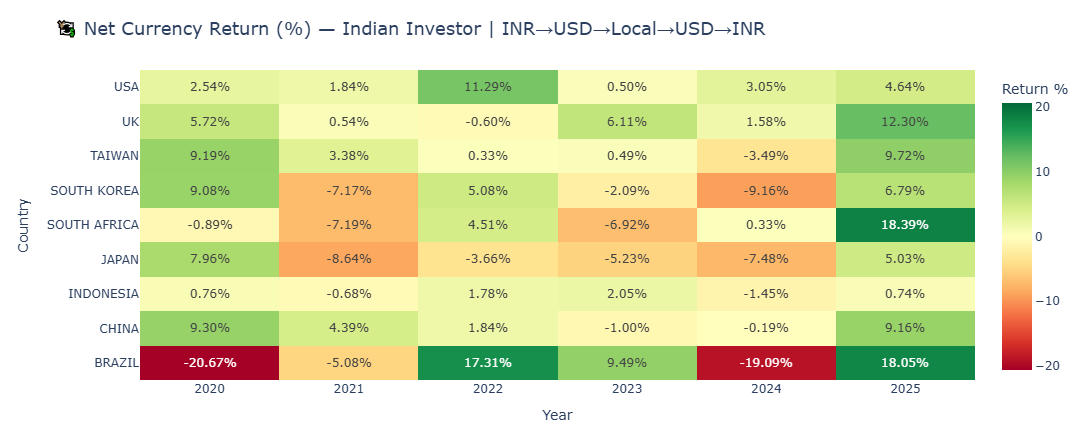

In [12]:
# ── Graph 1: Heatmap — Net Currency Return by Country × Year ──
fig = go.Figure(data=go.Heatmap(
    z=net_pivot.values,
    x=[str(c) for c in net_pivot.columns],
    y=net_pivot.index.tolist(),
    colorscale='RdYlGn',
    zmid=0,
    text=[[f'{v:.2f}%' for v in row] for row in net_pivot.values],
    texttemplate='%{text}',
    textfont={'size': 12},
    showscale=True,
    colorbar=dict(title='Return %')
))
fig.update_layout(
    title=dict(text='💱 Net Currency Return (%) — Indian Investor | INR→USD→Local→USD→INR', font=dict(size=18)),
    xaxis_title='Year',
    yaxis_title='Country',
    height=440,
    margin=dict(l=140, r=40, t=70, b=60)
)
fig.show()

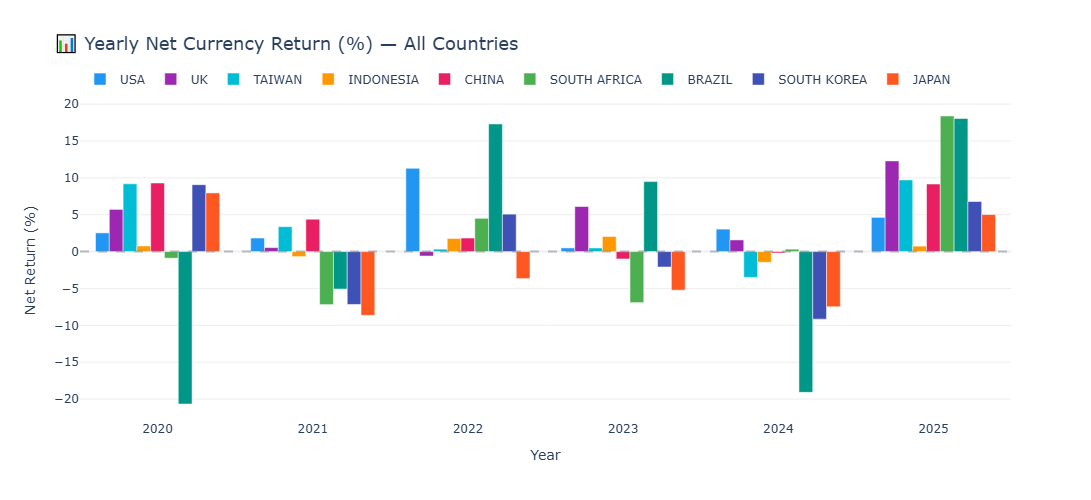

In [13]:
# ── Graph 2: Grouped Bar — Net Return per Year, grouped by Country ──
fig = go.Figure()
for country in COUNTRIES:
    df_c = results_df[results_df['Country'] == country].sort_values('Year')
    fig.add_trace(go.Bar(
        name=country,
        x=[str(y) for y in df_c['Year']],
        y=df_c['Net Return (%)'],
        marker_color=COUNTRY_COLORS[country]
    ))

fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig.update_layout(
    title=dict(text='📊 Yearly Net Currency Return (%) — All Countries', font=dict(size=18)),
    barmode='group',
    xaxis_title='Year',
    yaxis_title='Net Return (%)',
    height=500,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

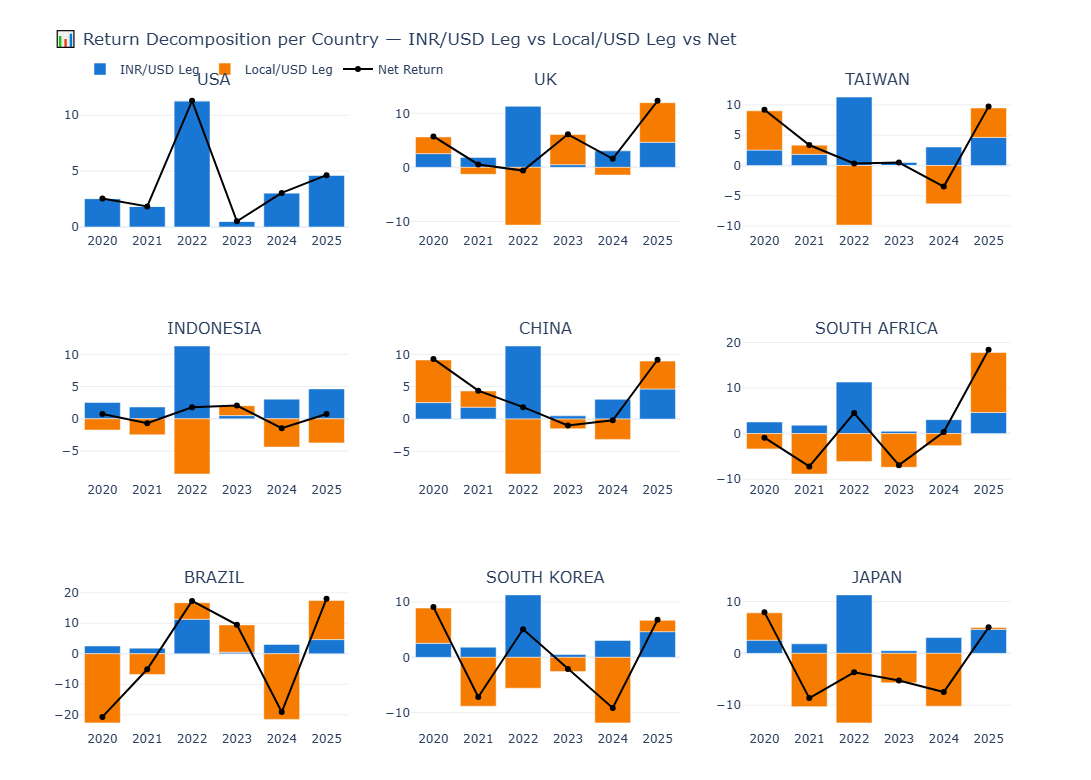

In [14]:
# ── Graph 3: Stacked Bar — USDINR leg vs Local/USD leg (for each country per year) ──
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=COUNTRIES,
    shared_yaxes=False
)

for idx, country in enumerate(COUNTRIES):
    row = idx // 3 + 1
    col = idx % 3 + 1
    df_c = results_df[results_df['Country'] == country].sort_values('Year')
    years_str = [str(y) for y in df_c['Year']]

    fig.add_trace(go.Bar(
        x=years_str,
        y=df_c['USDINR Return (%)'],
        name='INR/USD Leg',
        marker_color='#1976D2',
        showlegend=(idx == 0)
    ), row=row, col=col)

    fig.add_trace(go.Bar(
        x=years_str,
        y=df_c['Local/USD Return (%)'],
        name='Local/USD Leg',
        marker_color='#F57C00',
        showlegend=(idx == 0)
    ), row=row, col=col)

    # Net return as a line
    fig.add_trace(go.Scatter(
        x=years_str,
        y=df_c['Net Return (%)'],
        name='Net Return',
        line=dict(color='black', width=2),
        mode='lines+markers',
        showlegend=(idx == 0)
    ), row=row, col=col)

fig.update_layout(
    title=dict(text='📊 Return Decomposition per Country — INR/USD Leg vs Local/USD Leg vs Net', font=dict(size=17)),
    barmode='relative',
    height=780,
    plot_bgcolor='rgba(0,0,0,0)',
    legend=dict(orientation='h', yanchor='bottom', y=1.01),
    margin=dict(t=90, b=50)
)
fig.update_yaxes(gridcolor='#eee')
fig.show()

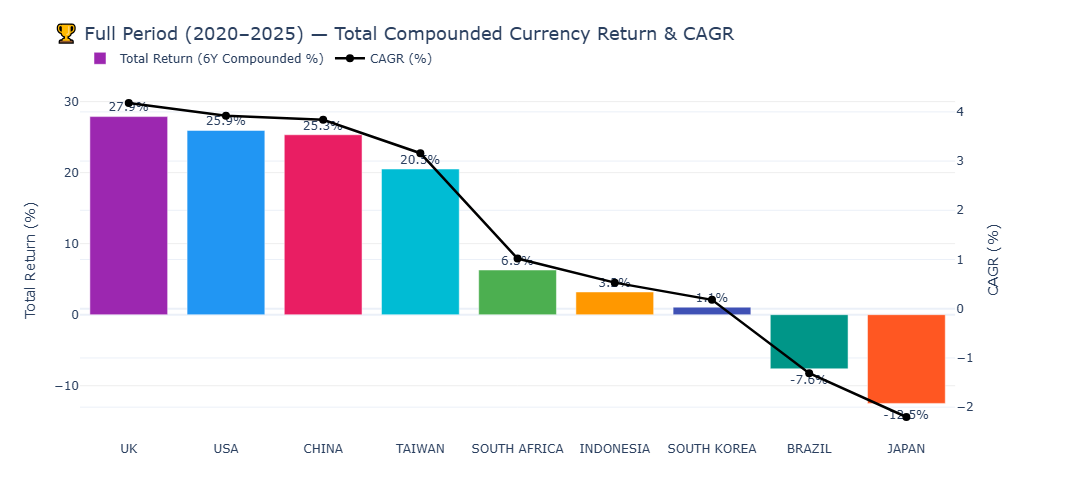

In [15]:
# ── Graph 4: Total Return bar + CAGR line ──
total_sorted = total_df.sort_values('Total Net Return (%)', ascending=False)

fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(go.Bar(
    x=total_sorted['Country'],
    y=total_sorted['Total Net Return (%)'],
    name='Total Return (6Y Compounded %)',
    marker_color=[COUNTRY_COLORS[c] for c in total_sorted['Country']],
    text=[f'{v:.1f}%' for v in total_sorted['Total Net Return (%)']],
    textposition='outside'
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=total_sorted['Country'],
    y=total_sorted['CAGR (%)'],
    name='CAGR (%)',
    line=dict(color='black', width=2.5),
    mode='lines+markers',
    marker=dict(size=8)
), secondary_y=True)

fig.update_layout(
    title=dict(text='🏆 Full Period (2020–2025) — Total Compounded Currency Return & CAGR', font=dict(size=18)),
    height=500,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee', title='Total Return (%)'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    margin=dict(t=80, b=60)
)
fig.update_yaxes(title_text='CAGR (%)', secondary_y=True)
fig.show()

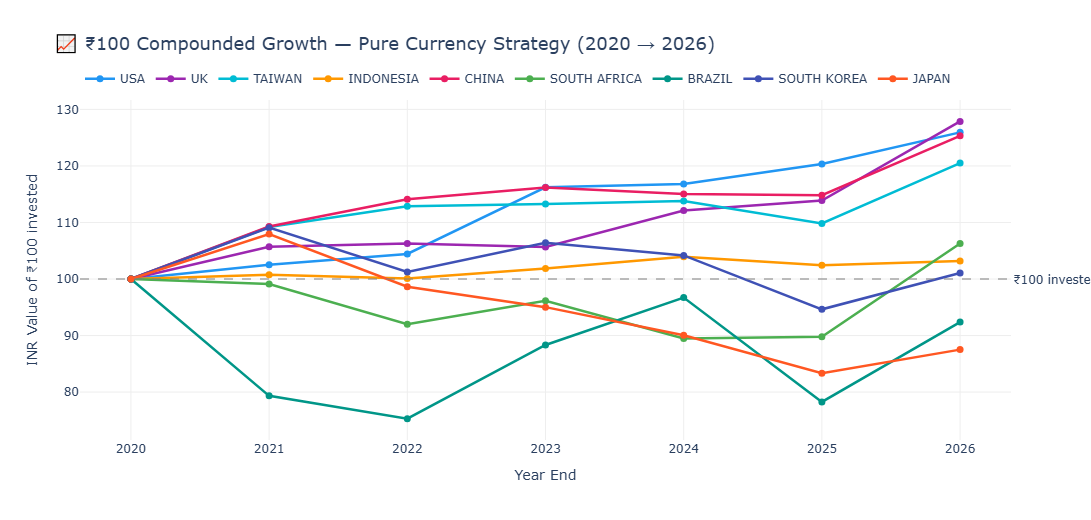

In [16]:
# ── Graph 5: Compounded INR Growth of ₹100 invested on 1-Jan-2020 ──
fig = go.Figure()

for country in COUNTRIES:
    df_c = results_df[results_df['Country'] == country].sort_values('Year')
    inr_val = [100.0]
    year_labels = [str(df_c['Year'].iloc[0])]

    for _, row in df_c.iterrows():
        inr_val.append(inr_val[-1] * (1 + row['Net Return (%)'] / 100))
        year_labels.append(str(int(row['Year']) + 1))

    fig.add_trace(go.Scatter(
        x=year_labels,
        y=inr_val,
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=2.5),
        mode='lines+markers',
        marker=dict(size=7)
    ))

fig.add_hline(y=100, line_dash='dash', line_color='gray', opacity=0.5,
              annotation_text='₹100 invested', annotation_position='right')
fig.update_layout(
    title=dict(text='📈 ₹100 Compounded Growth — Pure Currency Strategy (2020 → 2026)', font=dict(size=18)),
    xaxis_title='Year End',
    yaxis_title='INR Value of ₹100 invested',
    height=520,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

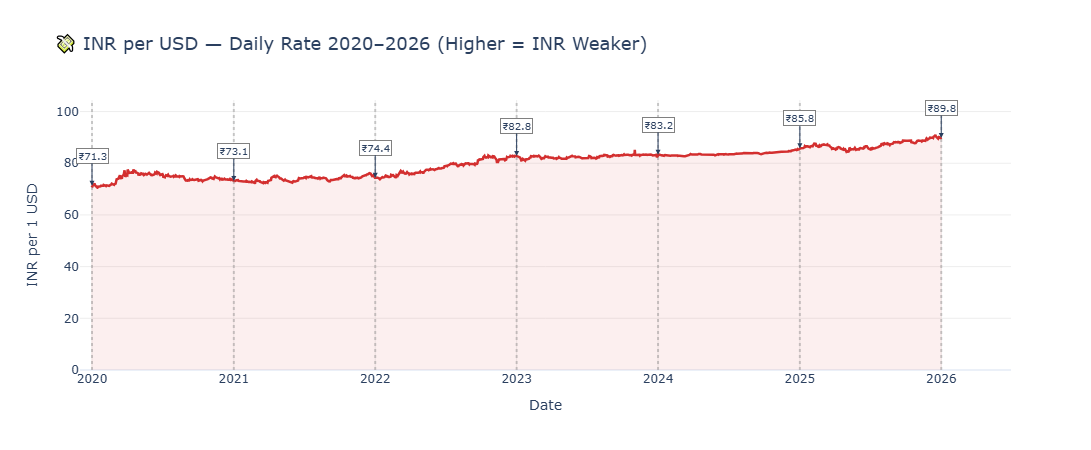

In [17]:
# ── Graph 6: INR/USD rate over the full period (to see depreciation trend) ──
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=inr_series.index,
    y=inr_series.values,
    line=dict(color='#D32F2F', width=2.5),
    fill='tozeroy',
    fillcolor='rgba(211,47,47,0.08)',
    name='INR per USD'
))

# Mark each 1-Jan
for year in YEARS + [2026]:
    rate = get_rate(inr_series, f'{year}-01-01')
    fig.add_vline(x=f'{year}-01-01', line_dash='dot', line_color='gray', opacity=0.4)
    fig.add_annotation(x=f'{year}-01-01', y=rate, text=f'₹{rate:.1f}',
                       showarrow=True, arrowhead=2, ax=0, ay=-30,
                       font=dict(size=10), bgcolor='white', bordercolor='gray')

fig.update_layout(
    title=dict(text='💸 INR per USD — Daily Rate 2020–2026 (Higher = INR Weaker)', font=dict(size=18)),
    xaxis_title='Date',
    yaxis_title='INR per 1 USD',
    height=450,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee', range=['2019-12-01', '2026-06-30'])
)
fig.show()

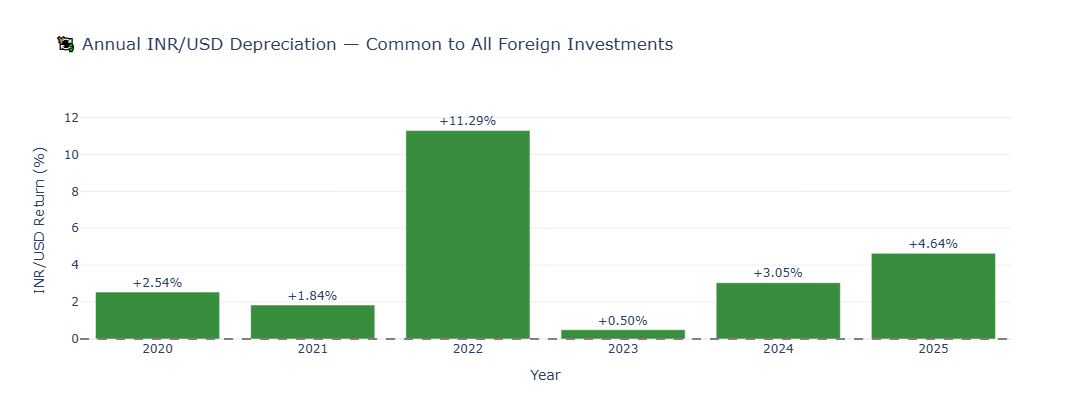

In [18]:
# ── Graph 7: USDINR annual contribution (same for all countries — show once cleanly) ──
usdinr_annual = results_df[results_df['Country'] == 'USA'][['Year','USDINR Return (%)']].sort_values('Year')

bar_colors = ['#388e3c' if v > 0 else '#d32f2f' for v in usdinr_annual['USDINR Return (%)']]

fig = go.Figure(go.Bar(
    x=[str(y) for y in usdinr_annual['Year']],
    y=usdinr_annual['USDINR Return (%)'],
    marker_color=bar_colors,
    text=[f'{v:+.2f}%' for v in usdinr_annual['USDINR Return (%)']],
    textposition='outside'
))
fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.update_layout(
    title=dict(text='💱 Annual INR/USD Depreciation — Common to All Foreign Investments', font=dict(size=17)),
    xaxis_title='Year',
    yaxis_title='INR/USD Return (%)',
    height=420,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    showlegend=False
)
fig.show()

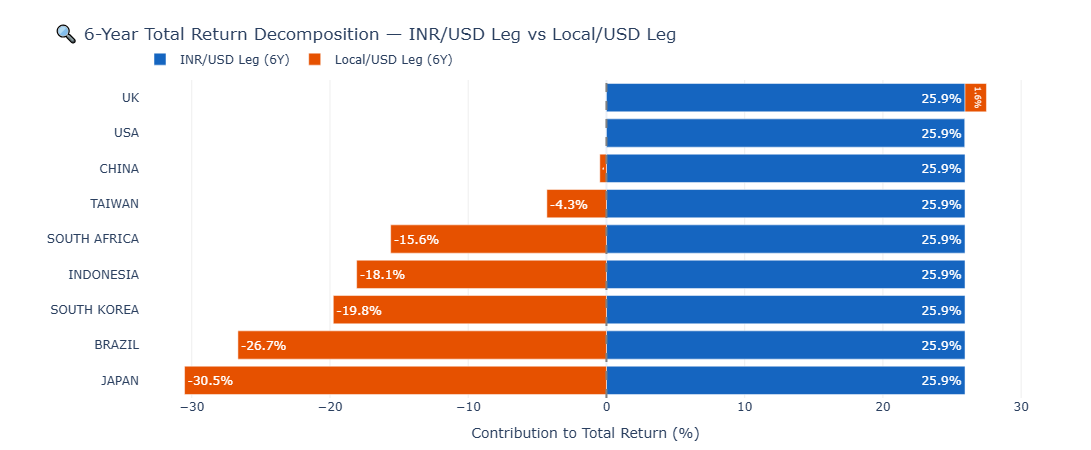

In [19]:
# ── Graph 8: Contribution breakdown for total period — stacked horizontal bar ──
total_sorted2 = total_df.sort_values('Total Net Return (%)')

fig = go.Figure()
fig.add_trace(go.Bar(
    y=total_sorted2['Country'],
    x=total_sorted2['USDINR Total Contribution'],
    name='INR/USD Leg (6Y)',
    orientation='h',
    marker_color='#1565C0',
    text=[f'{v:.1f}%' for v in total_sorted2['USDINR Total Contribution']],
    textposition='inside'
))
fig.add_trace(go.Bar(
    y=total_sorted2['Country'],
    x=total_sorted2['Local/USD Total Contribution'],
    name='Local/USD Leg (6Y)',
    orientation='h',
    marker_color='#E65100',
    text=[f'{v:.1f}%' for v in total_sorted2['Local/USD Total Contribution']],
    textposition='inside'
))

fig.update_layout(
    title=dict(text='🔍 6-Year Total Return Decomposition — INR/USD Leg vs Local/USD Leg', font=dict(size=17)),
    barmode='relative',
    xaxis_title='Contribution to Total Return (%)',
    height=450,
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis=dict(gridcolor='#eee'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    margin=dict(l=140, r=60, t=80, b=50)
)
fig.add_vline(x=0, line_dash='dash', line_color='gray')
fig.show()

## 8. 📝 Final Summary Table — Everything in One Place

In [20]:
print('=' * 80)
print('  PURE CURRENCY RETURN ANALYSIS — INDIAN INVESTOR — COMPLETE SUMMARY')
print('  Strategy: INR → USD → Local Currency, hold 1 year, reverse')
print('=' * 80)

print('\n📋 YEARLY NET RETURN TABLE (rows = country, cols = year):')
print(net_pivot.to_string(float_format=lambda x: f'{x:+.2f}%'))

print('\n\n📋 FULL PERIOD SUMMARY:')
print(total_df[['Country','Total Net Return (%)','CAGR (%)','USDINR Total Contribution','Local/USD Total Contribution']]
      .to_string(index=False, float_format=lambda x: f'{x:+.2f}%'))

print('\n\n🏆 BEST CURRENCY to hold (highest 6Y total return):', total_df.iloc[0]['Country'])
print('⚠️  WORST CURRENCY to hold (lowest 6Y total return): ', total_df.iloc[-1]['Country'])

# INR total depreciation vs USD over full period
inr_2020 = get_rate(inr_series, '2020-01-01')
inr_2026 = get_rate(inr_series, '2026-01-01')
inr_total_dep = (inr_2026 / inr_2020 - 1) * 100
print(f'\n💸 INR TOTAL DEPRECIATION vs USD (Jan 2020 → Jan 2026): {inr_total_dep:+.2f}%')
print(f'   (₹{inr_2020:.2f}/USD → ₹{inr_2026:.2f}/USD)')
print('   This depreciation ADDED to your return on ALL foreign investments')
print('=' * 80)

  PURE CURRENCY RETURN ANALYSIS — INDIAN INVESTOR — COMPLETE SUMMARY
  Strategy: INR → USD → Local Currency, hold 1 year, reverse

📋 YEARLY NET RETURN TABLE (rows = country, cols = year):
                2020   2021    2022   2023    2024    2025
Country                                                   
BRAZIL       -20.67% -5.08% +17.31% +9.49% -19.09% +18.05%
CHINA         +9.30% +4.39%  +1.84% -1.00%  -0.19%  +9.16%
INDONESIA     +0.76% -0.68%  +1.78% +2.05%  -1.45%  +0.74%
JAPAN         +7.96% -8.64%  -3.66% -5.23%  -7.48%  +5.03%
SOUTH AFRICA  -0.89% -7.19%  +4.51% -6.92%  +0.33% +18.39%
SOUTH KOREA   +9.08% -7.17%  +5.08% -2.09%  -9.16%  +6.79%
TAIWAN        +9.19% +3.38%  +0.33% +0.49%  -3.49%  +9.72%
UK            +5.72% +0.54%  -0.60% +6.11%  +1.58% +12.30%
USA           +2.54% +1.84% +11.29% +0.50%  +3.05%  +4.64%


📋 FULL PERIOD SUMMARY:
     Country  Total Net Return (%)  CAGR (%)  USDINR Total Contribution  Local/USD Total Contribution
          UK               +27.89%  